# Lista 3 - Séries Temporais


---

### Enunciado:

*Ajustar um modelo para duas séries.*

*Se quiserem tentem ajustar modelo para alguma série de https://finance.yahoo.com/*

*fiquem à vontade.*

---

# 📈 Análise de Séries Temporais em R

Este notebook apresenta o **procedimento** para análise de séries temporais, seguindo a metodologia:

1. Carregamento e visualização dos dados
2. Decomposição da série
3. Teste de estacionariedade
4. Transformações (se necessário)
5. Identificação do modelo (ACF / PACF)
6. Ajuste do modelo ARIMA
7. Diagnóstico dos resíduos
8. Previsão


---


In [64]:
library(forecast)
library(tseries)
library(ggplot2)
library(zoo)
library(quantmod)
library(astsa)

---

### Série 1

Usaremos a série `unemp` — taxa de desemprego (unemployment rate) dos Estados Unidos de 1890 a 1988.

---
## 1. Carregamento e visualização inicial

O primeiro passo é **olhar pros dados**. Queremos entender:
- Existe **tendência** (crescimento ou queda ao longo do tempo)?
- Existe **sazonalidade** (padrões que se repetem periodicamente)?
- Tem anormalidade?
- A variância é **constante** ou cresce com o tempo?


In [35]:
# 1. Pegar os dados NelPlo do pacote tseries
data(NelPlo)

# 2. Extrair a série unemp como ts
ts_data <- NelPlo[, "unemp"]

# 3. Tirar NAs que estão no começo da série pois a série de interesse começa a ser registrada depois
dados_sem_na <- na.omit(as.numeric(ts_data))
novo_start <- start(ts_data) + c(0, (min(which(!is.na(ts_data)))-1) / frequency(ts_data))
ts_limpa <- ts(dados_sem_na, start = novo_start, frequency= frequency(ts_data))

# 4. objeto ts que vamos usar
ts_data <- ts_limpa

# Informações básicas
cat("Classe:", class(ts_data), "\n")
cat("Início:", start(ts_data), "\n")
cat("Fim:", end(ts_data), "\n")
cat("Frequência:", frequency(ts_data), "observações/ano\n")
cat("Comprimento:", length(ts_data), "observações\n")
cat("\nResumo estatístico:\n")
print(summary(ts_data))

Classe: ts 
Início: 1890 1 
Fim: 1988 1 
Frequência: 1 observações/ano
Comprimento: 99 observações

Resumo estatístico:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1823  1.3736  1.7047  1.7514  2.0540  3.2149 


Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."


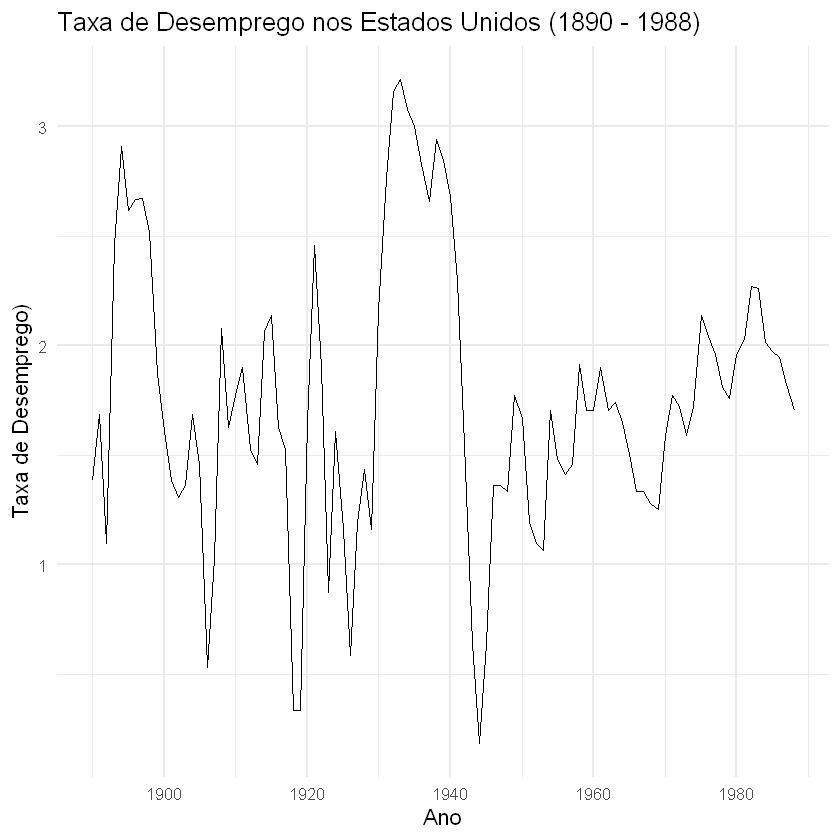

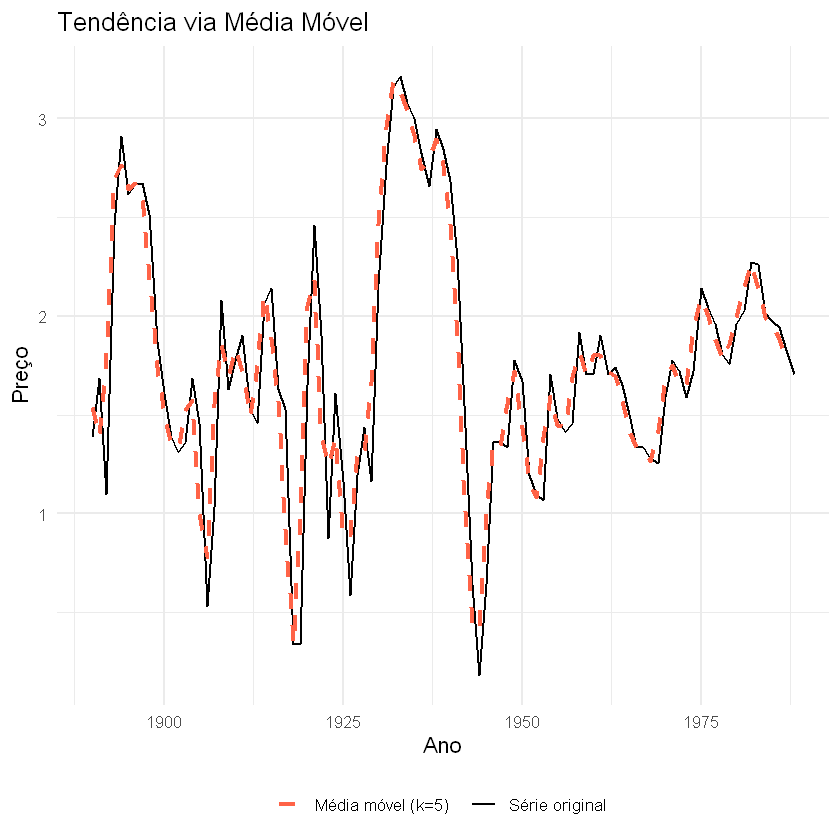

In [45]:
# Visualização da série original
autoplot(ts_data) +
  labs(
    title = "Taxa de Desemprego nos Estados Unidos (1890 - 1988)",
    x = "Ano",
    y = "Taxa de Desemprego)"
  ) +
  theme_minimal(base_size = 13)

# Visualização de média móvel
tendencia <- rollmean(ts_data, k = 2, fill = NA)

df_plot <- data.frame(
  ano       = as.numeric(time(ts_data)),
  original  = as.numeric(ts_data),
  tendencia = as.numeric(tendencia)
)

ggplot(df_plot, aes(x = ano)) +
  geom_line(aes(y = original,  color = "Série original"), linewidth = 0.8) +
  geom_line(aes(y = tendencia, color = "Média móvel (k=5)"), linewidth = 1.2, linetype = "dashed") +
  scale_color_manual(values = c("Série original" = "black", "Média móvel (k=5)" = "tomato")) +
  labs(title = "Tendência via Média Móvel", x = "Ano", y = "Preço", color = NULL) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")

**Observações da visualização:**

- Não há uma tendência decrescente clara ao longo de todo o período. A série oscila bastante e apresenta diferentes fases de crescimento e queda
- Existem períodis de forte variação, uns picos mais acentuados entre 1930 e 1940, e umas quedas(vales) em torno de 1915-1920 e 1940-1945
- A homocedasticidade não é muito evidente já que a amplitude das oscilações parece variar ao longo do tempo, especialmente entre as décadas 1920 e 1940 que aparenta ter uma variação maior.
- A série parace ter um comportamento periódico que pode indicar a presença de sazonalidade, embora não é muito identificável (o que também é esperado para os dados anuais).
- O gráfcico de média móvel mostra as mesmas característica descritas acima.

---
## 2. Decomposição da série

Não vamos decompor a série pois a frequência de dados é 1 (são dados anuais), ou seja não tem sazonalidade.

---
## 3. Teste de Estacionariedade

Queremos ajustar um modelo ARIMA para os dados. (Não é SARIMA pois não tem sazonalidade).

Modelos ARIMA exigem série **estacionária** (média e variância constantes no tempo).

Para confirmar nossa suspeita de tendencia, Vamos realizar os testes de Dickey-Fuller Aumentado que verifica se a série é estacionária.

- **ADF**: $H_0$ = tem raiz unitária (não estacionária). $p < 0{,}05$ → estacionária.

Usando a função "adf.test" do R temos um valor-p de 0.0556. Assim não rejeitamos a hipótese de que a série tem tendência ao nível de 5%.

In [37]:
adf.test(ts_data)


	Augmented Dickey-Fuller Test

data:  ts_data
Dickey-Fuller = -3.4183, Lag order = 4, p-value = 0.0556
alternative hypothesis: stationary


---
## 4. Transformações para Estacionarizar

Como a série **pode não ser estacionária**, aplicamos:

- **Diferenciação simples** — para remover tendência.

Usamos `ndiffs()` para determinar automaticamente o número de diferenças necessárias.

Porém R nos retornou que o número de diferenças necessárias é 0, isso pode indicar que nos outros testes (aém do ADF) de Tendência vs Estaionariedade a nossa série é considerada como estacionária. Com o valor-p de 0.0556 do teste de ADF, pelo princípio da parcimonia, nós iremos mudar de ideia e considerar que é plasível determinar que a série ja é estacionária ao nível de 10%.

---
## 5. Identificação do Modelo — ACF e PACF

Com a série estacionária, para identificar as ordens $p$ e $q$ podemos usar ACF e PACF como referência:

| Padrão observado | Interpretação |
|-----------------|---------------|
| ACF corta no lag $q$, PACF decai | Processo **MA(q)** |
| PACF corta no lag $p$, ACF decai | Processo **AR(p)** |
| Ambos decaem gradualmente | Processo **ARMA(p,q)** |

Com o gráfico de ACF e PACF abaixo, podemos ver que em 

- ACF:
 Lag 1 bem alto, lag 2 e lag 3 ainda significativo, e a partir do lag 4 entra no intervalo

- PACF:
 Lag 1 alto, lag 2 é negativo e significativo e depois fica dentro do intervalo.

Isso pode indicar que talvez o modelo seja um ARIMA(2,0,0)

Mas no próximo passo iremos escolher com a função auto.arima do R para ver o que as ferramentas sugerem.

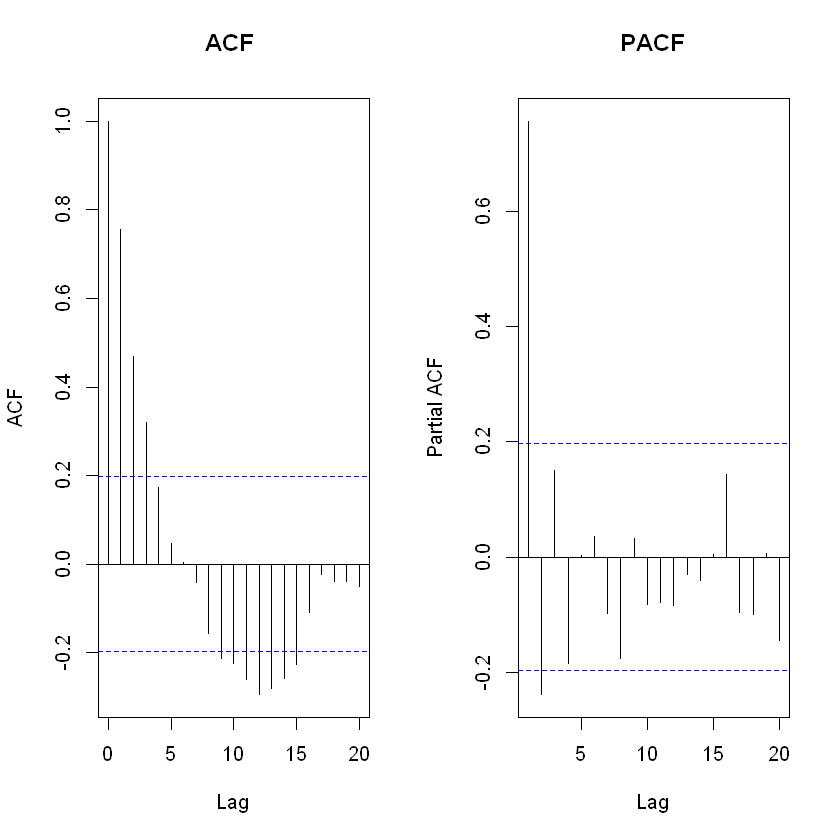

In [42]:
par(mfrow = c(1, 2))
acf(ts_data,  lag.max = 20, main = "ACF ")
pacf(ts_data, lag.max = 20, main = "PACF")

---
## 6. Ajuste do Modelo ARIMA

Podemos tanto **especificar manualmente** quanto usar o `auto.arima()` que testa automaticamente as combinações via critério de informação (AIC/BIC).

Com a saída do código abaixo, e pelo menor AIC, iremos ficar com o modelo ARIMA(1,0,1) que é um modelo ARMA(1,1)

In [48]:
modelo_auto <- auto.arima(
  ts_data
)

cat("\n=== Modelo selecionado automaticamente ===\n")
summary(modelo_auto)


=== Modelo selecionado automaticamente ===


Series: ts_data 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
         ar1     ma1    mean
      0.5269  0.5546  1.7374
s.e.  0.1098  0.1311  0.1274

sigma^2 = 0.158:  log likelihood = -48.22
AIC=104.43   AICc=104.86   BIC=114.81

Training set error measures:
                      ME      RMSE       MAE       MPE     MAPE      MASE
Training set 0.004466967 0.3914123 0.2898267 -10.81206 25.33637 0.9151758
                    ACF1
Training set -0.04648874

---
## 7. Diagnóstico dos Resíduos

Tendo um modelo ajustado (ARIMA(1,0,1)) agora, podemos ver os resíduos.

Um bom modelo deve ter resíduos que se comportem como **ruído branco**:

- Média ≈ 0
- Variância constante (homocedasticidade)
- Sem autocorrelação significativa
- Distribuição aproximadamente normal

Um teste adequado nesse caso é o **Teste de Ljung-Box**: $H_0$ = não há autocorrelação nos resíduos.

Abaixo está um conjunto de gráfico feito com a função sarima do pacote astsa. E dá para ver que os resíduo comportam do jeito esperado:


- A média dos resíduos está em torno de zero

- Parecem homocedásticos e normais

- e o teste de Ljung-Box é feito para vário lags no último gráfico, isso nos diz que a hipótese de que os resíduos são ruídos branco não é rejeitada.

initial  value -0.451191 
iter   2 value -0.816312
iter   3 value -0.918728
iter   4 value -0.929643
iter   5 value -0.932677
iter   6 value -0.934289
iter   7 value -0.934414
iter   8 value -0.934419
iter   9 value -0.934421
iter  10 value -0.934423
iter  11 value -0.934424
iter  12 value -0.934424
iter  12 value -0.934424
iter  12 value -0.934424
final  value -0.934424 
converged
initial  value -0.931355 
iter   2 value -0.931638
iter   3 value -0.931812
iter   4 value -0.931905
iter   5 value -0.931906
iter   6 value -0.931906
iter   7 value -0.931906
iter   7 value -0.931906
iter   7 value -0.931906
final  value -0.931906 
converged
<><><><><><><><><><><><><><>
 
Coefficients: 
      Estimate     SE t.value p.value
ar1     0.5269 0.1098  4.7983   0e+00
ma1     0.5546 0.1311  4.2307   1e-04
xmean   1.7374 0.1274 13.6335   0e+00

sigma^2 estimated as 0.1532036 on 96 degrees of freedom 
 
AIC = 1.054874  AICc = 1.057426  BIC = 1.159727 
 


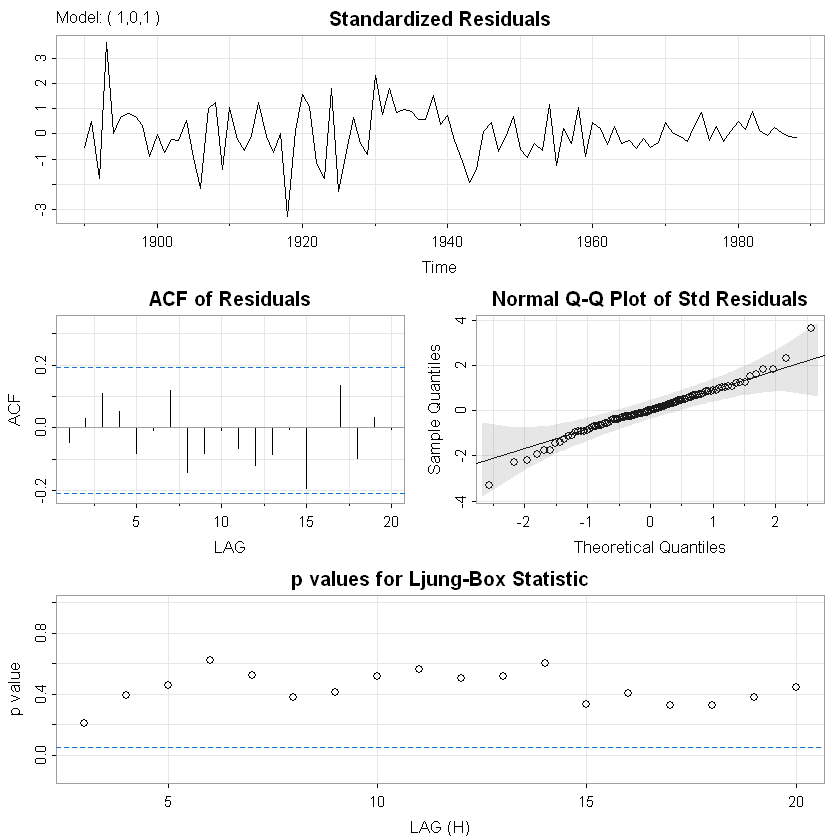

In [61]:
sarima(ts_data,1,0,1)

---
## 8. Previsão (*Forecast*)

O nosso modelo é validado, iremos gerar previsões (foco de horizonte = h = 5).

```

Point Forecast     Lo 80    Hi 80     Lo 95    Hi 95
1989       1.687894 1.1785011 2.197286 0.9088450 2.466942
1990       1.711332 0.9610145 2.461650 0.5638202 2.858845
1991       1.723682 0.9191736 2.528191 0.4932923 2.954072
1992       1.730190 0.9112718 2.549107 0.4777630 2.982616
1993       1.733618 0.9107450 2.556491 0.4751422 2.992094

```

O gráfico abaixo mostra uma visualização melhor das previsões (dentro do intervalo azul).

     Point Forecast     Lo 80    Hi 80     Lo 95    Hi 95
1989       1.687894 1.1785011 2.197286 0.9088450 2.466942
1990       1.711332 0.9610145 2.461650 0.5638202 2.858845
1991       1.723682 0.9191736 2.528191 0.4932923 2.954072
1992       1.730190 0.9112718 2.549107 0.4777630 2.982616
1993       1.733618 0.9107450 2.556491 0.4751422 2.992094

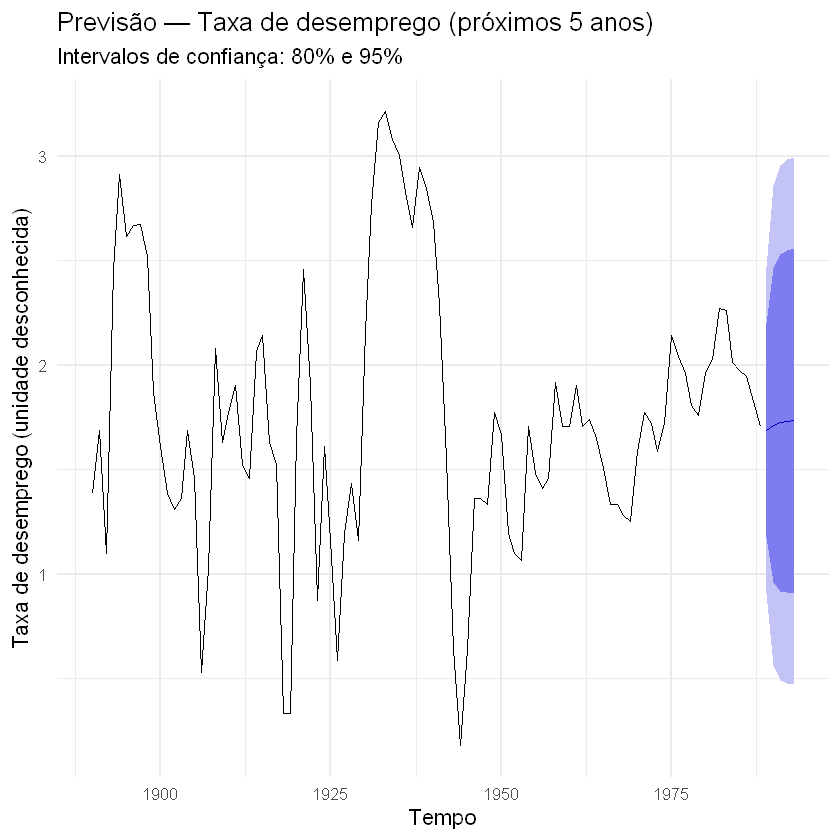

In [60]:
h <- 5  # horizonte de previsão

previsao <- forecast(modelo_auto, h = h, level = c(80, 95))
previsao
# Revertendo a transformação logarítmica
previsao_orig <- previsao
previsao_orig$mean  <- (previsao$mean)
previsao_orig$lower <- (previsao$lower)
previsao_orig$upper <- (previsao$upper)
previsao_orig$x     <- (previsao$x)

# Plot
autoplot(previsao_orig) +
  labs(
    title    = "Previsão — Taxa de desemprego (próximos 5 anos)",
    subtitle = "Intervalos de confiança: 80% e 95%",
    x        = "Tempo",
    y        = "Taxa de desemprego (unidade desconhecida)"
  ) +
  theme_minimal(base_size = 13)

---

### Série 2

Usaremos a série `MSFT` — preço das ações da empresa Microsoft de 2020 a 2026.

In [1]:
msft_data <- getSymbols("MSFT", 
                        src = "yahoo", 
                        from = "2020-01-01", 
                        to = "2026-05-29", 
                        auto.assign = FALSE)

preco <- msft_data[, "MSFT.Adjusted"]
preco <- as.numeric(preco)
ts_data <- ts(preco, frequency = 252)


ERROR: Error in getSymbols("MSFT", src = "yahoo", from = "2020-01-01", to = "2026-05-29", : não foi possível encontrar a função "getSymbols"


---
## 1. Carregamento e visualização inicial

**Olhar pros dados**.



Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."


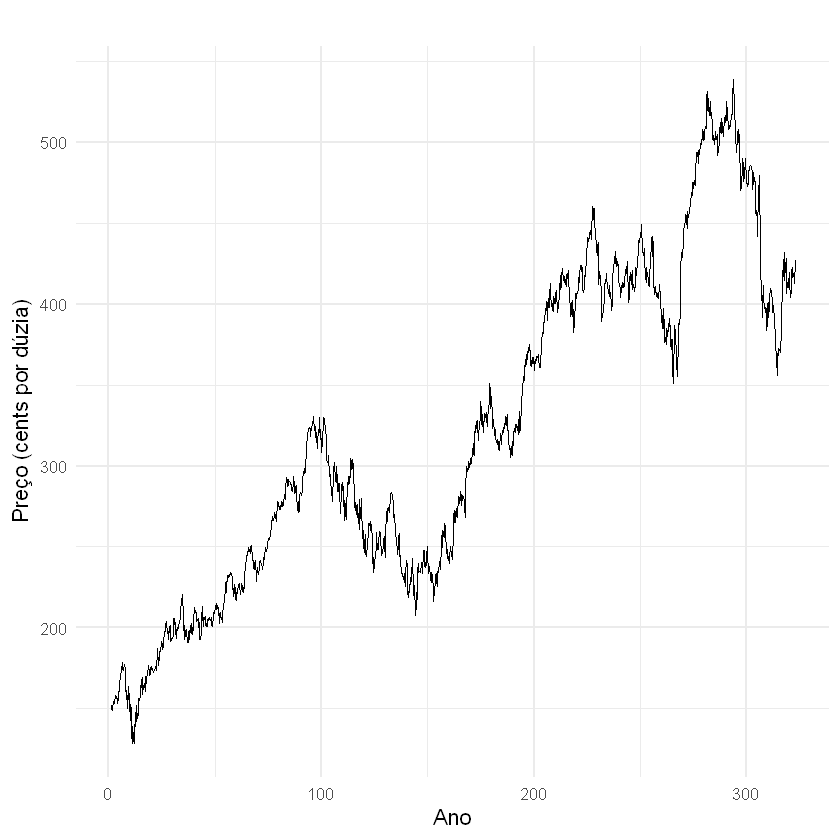

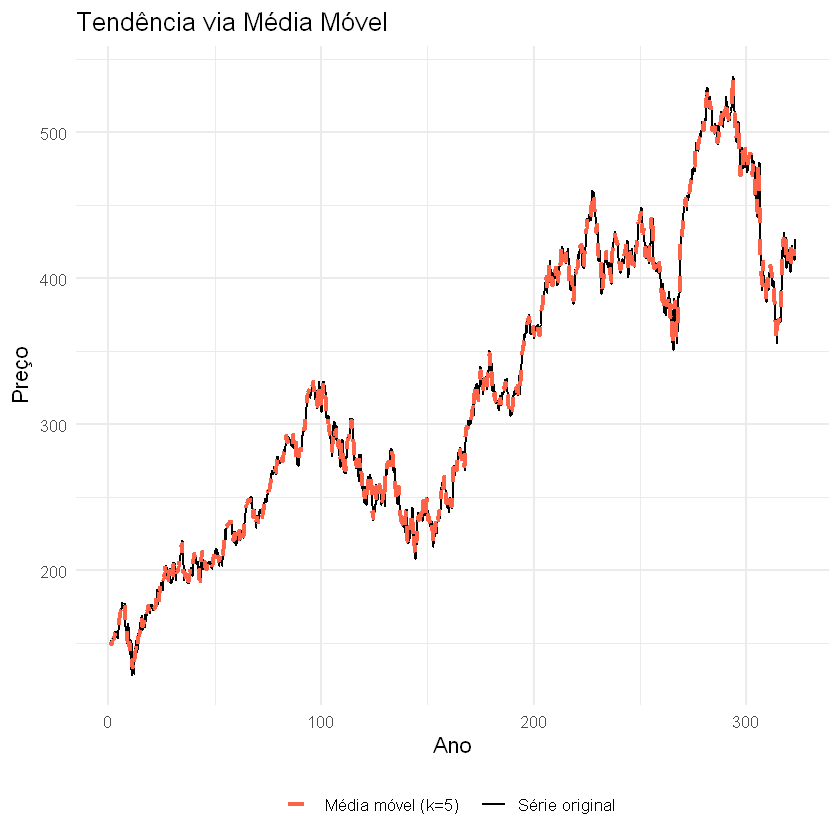

In [69]:
autoplot(ts_data) +
  labs(
    title = "",
    x     = "Ano",
    y     = "Preço (cents por dúzia)"
  ) +
  theme_minimal(base_size = 13)

# Visualização de média móvel
tendencia <- rollmean(ts_data, k = 2, fill = NA)

df_plot <- data.frame(
  ano       = as.numeric(time(ts_data)),
  original  = as.numeric(ts_data),
  tendencia = as.numeric(tendencia)
)

ggplot(df_plot, aes(x = ano)) +
  geom_line(aes(y = original,  color = "Série original"), linewidth = 0.8) +
  geom_line(aes(y = tendencia, color = "Média móvel (k=5)"), linewidth = 1.2, linetype = "dashed") +
  scale_color_manual(values = c("Série original" = "black", "Média móvel (k=5)" = "tomato")) +
  labs(title = "Tendência via Média Móvel", x = "Ano", y = "Preço", color = NULL) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")

**Observações da visualização:**

- Há uma **tendência crescente de longo prazo** ao longo da série, embora sejam observados diversos movimentos de alta e baixa no curto prazo.
- A série apresenta **períodos de elevada volatilidade**, com oscilações mais intensas principalmente entre as observações 200 e 320.
- A **variância não parece constante ao longo do tempo** (possível heterocedasticidade), uma vez que a amplitude das flutuações aumenta à medida que o nível da série cresce.
- Não há evidências visuais claras de **sazonalidade**, pois não se observa um padrão regular e repetitivo de ciclos ao longo do período.
- Observam-se alguns movimentos abruptos de queda e recuperação, especialmente próximo ao final da série, que podem estar associados a choques temporários ou mudanças nas condições do processo gerador dos dados.
- O gráfico sugere que a série **não é estacionária em média**, devido à presença de tendência e possíveis mudanças na variabilidade ao longo do tempo.
- O gráfico de média móvel tende a suavizar as oscilações de curto prazo e reforça a percepção da tendência crescente observada na série original.

---
## 2. Decomposição da série

